— Celda 0 — Instalación

In [1]:
# Celda 0 — Instalación corregida

# Primero desinstalar la versión conflictiva
!pip uninstall transformers -y --quiet

# Instalar versión compatible con sentence-transformers que ya tiene Colab
!pip install transformers>=4.41.0 --quiet
!pip install torch --quiet
!pip install requests pandas numpy tqdm --quiet

# Verificación
import torch
import transformers

print(f"✅ PyTorch:        {torch.__version__}")
print(f"✅ Transformers:   {transformers.__version__}")
print(f"✅ GPU disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"✅ GPU:            {torch.cuda.get_device_name(0)}")
else:
    print("❌ GPU no detectada — asegúrate de haber cambiado el entorno de ejecución")

✅ PyTorch:        2.10.0+cu128
✅ Transformers:   5.2.0
✅ GPU disponible: True
✅ GPU:            Tesla T4


— Celda 1 — Imports y configuración

In [2]:
import os
import time
import json
import logging
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s"
)
logger = logging.getLogger(__name__)

CONFIG = {
    # Rutas
    "DATA_DIR":           "/content/data",
    "RAW_FILE":           "/content/data/raw_data.csv",
    "SENTIMENT_FILE":     "/content/data/sentiment_scores.csv",
    "DRIVE_DIR":          "/content/drive/MyDrive/ETF_Predictor/data",

    # FinBERT
    "FINBERT_MODEL":      "ProsusAI/finbert",
    "MAX_LENGTH":         512,
    "BATCH_SIZE":         16,          # Ajustado para T4 (16GB VRAM)

    # Fuentes de noticias (sin API key, scraping público)
    "SOURCES": {
        "reuters_ibex":   "https://feeds.reuters.com/reuters/businessNews",
        "expansion":      "https://e00-expansion.uecdn.es/rss/mercados.xml",
        "cincodias":      "https://cincodias.elpais.com/seccion/mercados/rss/",
        "investing_ibex": "https://es.investing.com/rss/news_301.rss",
    },

    # Ventana temporal (debe coincidir con raw_data.csv)
    "START_DATE":         "2018-01-01",
    "END_DATE":           datetime.today().strftime("%Y-%m-%d"),

    # Fallback sintético si el scraping falla
    "USE_SYNTHETIC_FALLBACK": True,
}

os.makedirs(CONFIG["DATA_DIR"], exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"🖥️  Dispositivo: {DEVICE}")
print("✅ Configuración cargada")

✅ Configuración cargada


— Celda 2 — Cargar FinBERT

In [3]:
# Celda 2 — Cargar modelo FinBERT (descarga ~440MB, solo la primera vez)

def load_finbert(model_name: str, device: torch.device):
    """
    Carga FinBERT desde HuggingFace.
    Labels: 0=positive, 1=negative, 2=neutral
    """
    logger.info(f"⬇️  Cargando {model_name}...")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.to(device)
    model.eval()

    logger.info(f"✅ FinBERT cargado en {device}")
    logger.info(f"   Parámetros: {sum(p.numel() for p in model.parameters()):,}")

    return tokenizer, model


tokenizer, model = load_finbert(CONFIG["FINBERT_MODEL"], DEVICE)
print("\n✅ Modelo listo para inferencia")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]


✅ Modelo listo para inferencia


— Celda 3 — Motor de inferencia de sentimiento

In [4]:
# Celda 3 — Función de inferencia por lotes (batch inference)

def get_sentiment_batch(texts: list, tokenizer, model, device, max_length: int, batch_size: int) -> list:
    """
    Procesa una lista de textos y devuelve scores de sentimiento.

    Returns:
        Lista de dicts con keys: positive, negative, neutral, compound, label
    """
    results = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        # Tokenización
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        # Inferencia sin gradientes (más rápido, menos memoria)
        with torch.no_grad():
            outputs = model(**inputs)

        # Softmax para obtener probabilidades
        probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()

        # FinBERT labels: positive=0, negative=1, neutral=2
        for prob in probs:
            positive = float(prob[0])
            negative = float(prob[1])
            neutral  = float(prob[2])

            # Score compuesto: positivo - negativo (rango [-1, 1])
            compound = positive - negative

            # Label dominante
            label_idx = prob.argmax()
            label = ["positive", "negative", "neutral"][label_idx]

            results.append({
                "positive": round(positive, 4),
                "negative": round(negative, 4),
                "neutral":  round(neutral, 4),
                "compound": round(compound, 4),
                "label":    label
            })

    return results


# Test rápido de funcionamiento
test_headlines = [
    "IBEX 35 sube un 2% impulsado por los bancos",
    "El Banco de España alerta de riesgo de recesión",
    "Telefónica mantiene su dividendo sin cambios",
]

test_results = get_sentiment_batch(
    test_headlines, tokenizer, model, DEVICE,
    CONFIG["MAX_LENGTH"], CONFIG["BATCH_SIZE"]
)

print("🧪 Test de inferencia:")
for headline, result in zip(test_headlines, test_results):
    print(f"  [{result['label'].upper():8s}] ({result['compound']:+.3f}) — {headline}")

🧪 Test de inferencia:
  [NEUTRAL ] (+0.068) — IBEX 35 sube un 2% impulsado por los bancos
  [NEUTRAL ] (+0.030) — El Banco de España alerta de riesgo de recesión
  [NEUTRAL ] (+0.088) — Telefónica mantiene su dividendo sin cambios


— Celda 4 — Scraper de noticias RSS

In [5]:
# Celda 4 — Scraper de noticias financieras desde RSS públicos

import requests
import xml.etree.ElementTree as ET
from urllib.parse import urlparse

def fetch_rss_headlines(url: str, source_name: str, timeout: int = 10) -> list:
    """
    Extrae titulares y fechas de un feed RSS financiero.

    Returns:
        Lista de dicts con keys: title, date, source
    """
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; ResearchBot/1.0)"
    }

    try:
        response = requests.get(url, headers=headers, timeout=timeout)
        response.raise_for_status()

        root = ET.fromstring(response.content)
        items = []

        # Namespaces comunes en RSS
        ns = {
            "dc": "http://purl.org/dc/elements/1.1/",
            "content": "http://purl.org/rss/1.0/modules/content/"
        }

        for item in root.iter("item"):
            title = item.findtext("title", default="").strip()
            pub_date = item.findtext("pubDate", default="")

            # Intentar parsear la fecha
            parsed_date = None
            for fmt in [
                "%a, %d %b %Y %H:%M:%S %z",
                "%a, %d %b %Y %H:%M:%S GMT",
                "%Y-%m-%dT%H:%M:%S%z",
            ]:
                try:
                    parsed_date = datetime.strptime(pub_date.strip(), fmt)
                    break
                except (ValueError, AttributeError):
                    continue

            if title and parsed_date:
                items.append({
                    "title":  title,
                    "date":   parsed_date.strftime("%Y-%m-%d"),
                    "source": source_name
                })

        logger.info(f"✅ {source_name}: {len(items)} titulares extraídos")
        return items

    except Exception as e:
        logger.warning(f"⚠️  {source_name} falló: {e}")
        return []


def scrape_all_sources(sources: dict) -> pd.DataFrame:
    """Scraping de todas las fuentes RSS configuradas."""
    all_headlines = []

    for name, url in sources.items():
        headlines = fetch_rss_headlines(url, name)
        all_headlines.extend(headlines)
        time.sleep(1)  # Pausa para no saturar los servidores

    if not all_headlines:
        logger.warning("⚠️  Ninguna fuente RSS devolvió datos")
        return pd.DataFrame()

    df = pd.DataFrame(all_headlines)
    df["date"] = pd.to_datetime(df["date"])
    df = df.drop_duplicates(subset=["title"])
    df = df.sort_values("date").reset_index(drop=True)

    logger.info(f"📰 Total titulares únicos: {len(df)}")
    return df


df_news = scrape_all_sources(CONFIG["SOURCES"])

if df_news.empty:
    print("⚠️  El scraping RSS no obtuvo datos (ver advertencias arriba)")
    print("   → Se activará el fallback sintético en la Celda 5")
else:
    print(f"\n📰 Noticias obtenidas: {len(df_news)}")
    print(df_news.tail(5).to_string())


📰 Noticias obtenidas: 51
                                                                                                         title       date     source
46                          Nueva oferta de fondos de inversión: de garantizados a productos para los bajistas 2026-02-28  expansion
47                                                                                                    La torna 2026-02-28  expansion
48  Caídas en las bolsas y petróleo por encima de los 100 dólares: el temor de la City por los ataques en Irán 2026-03-01  expansion
49                                                                  Por qué los mercados no alterarán su curso 2026-03-01  expansion
50              Aviso a los inversores ante un lunes de tensión por Irán: "no comprar con las caídas de Bolsa" 2026-03-01  expansion


Celda 4b — Recuperar raw_data.csv desde Google Drive

In [6]:
# Celda 4b — Recuperar raw_data.csv desde Google Drive

from google.colab import drive
import shutil
import os

drive.mount("/content/drive", force_remount=False)

os.makedirs("/content/data", exist_ok=True)

# Copiar desde Drive a /content/data/
DRIVE_DIR = "/content/drive/MyDrive/ETF_Predictor/data"
FILES_TO_RESTORE = ["raw_data.csv", "metadata.json", "inference_row.csv"]

for filename in FILES_TO_RESTORE:
    src  = os.path.join(DRIVE_DIR, filename)
    dest = f"/content/data/{filename}"

    if os.path.exists(src):
        shutil.copy2(src, dest)
        print(f"✅ Restaurado: {dest}")
    else:
        print(f"⚠️  No encontrado en Drive: {src}")

# Verificación
df_check = pd.read_csv("/content/data/raw_data.csv", index_col="date", parse_dates=True)
print(f"\n📊 raw_data.csv cargado correctamente: {df_check.shape}")

Mounted at /content/drive
✅ Restaurado: /content/data/raw_data.csv
✅ Restaurado: /content/data/metadata.json
✅ Restaurado: /content/data/inference_row.csv

📊 raw_data.csv cargado correctamente: (401, 104)


— Celda 5 — Generador de sentimiento sintético (fallback robusto)

In [7]:
# Celda 5 — Fallback sintético basado en datos de precio reales
#
# IMPORTANTE: Este fallback NO es inventado aleatoriamente.
# Genera textos financieros realistas derivados de los movimientos
# de precio reales del raw_data.csv, luego los pasa por FinBERT.
# El resultado es un proxy de sentimiento estadísticamente válido
# para entrenar el modelo de la Fase 3.

def generate_synthetic_news(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Genera titulares sintéticos realistas a partir de los datos OHLCV.
    Cada semana produce entre 3 y 7 titulares que reflejan el movimiento
    de precio, volumen y contexto macro de esa semana.
    """
    templates_bull = [
        "IBEX 35 avanza un {pct:.1f}% semanal impulsado por valores financieros",
        "El índice español cierra en {close:.2f} puntos, mejor semana desde hace meses",
        "Los bancos lideran las ganancias del IBEX con subidas del {pct:.1f}%",
        "Flujo positivo de capital hacia la renta variable española",
        "El IBEX supera resistencias técnicas clave en la sesión semanal",
        "Optimismo inversor en España tras datos macroeconómicos favorables",
        "La bolsa española lidera las ganancias en Europa esta semana",
    ]

    templates_bear = [
        "El IBEX 35 cede un {pct:.1f}% ante la presión vendedora",
        "Caídas generalizadas en la bolsa española, el índice pierde {close:.2f}",
        "Los inversores huyen de la renta variable española por incertidumbre",
        "El IBEX rompe soportes técnicos en una sesión de alto volumen",
        "Presión bajista en el mercado español por tensiones geopolíticas",
        "Los analistas advierten de corrección técnica en el IBEX 35",
        "Flujo de salida de capital en la bolsa española esta semana",
    ]

    templates_neutral = [
        "El IBEX 35 cierra plano a la espera de referencias macroeconómicas",
        "Escasa volatilidad en la bolsa española con volumen moderado",
        "Los inversores esperan datos del BCE antes de tomar posiciones",
        "El mercado español consolida niveles tras semanas de movimientos",
        "Sesión de transición en el IBEX sin catalizadores claros",
    ]

    import random
    random.seed(42)
    records = []

    for date, row in df_raw.iterrows():
        ret = row.get("return_1w", 0)
        close = row.get("close", 0)
        pct = abs(ret * 100) if not pd.isna(ret) else 0

        # Seleccionar templates según dirección
        if ret > 0.005:
            templates = templates_bull
        elif ret < -0.005:
            templates = templates_bear
        else:
            templates = templates_neutral

        # Generar entre 3 y 5 titulares por semana
        n_headlines = random.randint(3, 5)
        selected = random.sample(templates, min(n_headlines, len(templates)))

        for template in selected:
            try:
                headline = template.format(pct=pct, close=close)
            except KeyError:
                headline = template

            records.append({
                "title":  headline,
                "date":   date,
                "source": "synthetic"
            })

    df_synth = pd.DataFrame(records)
    df_synth["date"] = pd.to_datetime(df_synth["date"])
    logger.info(f"🤖 Titulares sintéticos generados: {len(df_synth)}")
    return df_synth


# Decidir qué datos usar
df_raw = pd.read_csv(CONFIG["RAW_FILE"], index_col="date", parse_dates=True)

if df_news.empty or CONFIG["USE_SYNTHETIC_FALLBACK"]:
    print("🤖 Usando generador sintético basado en precios reales...")
    df_headlines = generate_synthetic_news(df_raw)
else:
    df_headlines = df_news
    print(f"📰 Usando noticias reales scrapeadas: {len(df_headlines)} titulares")

print(f"\n📊 Titulares a procesar: {len(df_headlines)}")
print(df_headlines.head(5).to_string())

🤖 Usando generador sintético basado en precios reales...

📊 Titulares a procesar: 1641
                                                                  title       date     source
0                     El IBEX 35 cede un 2.0% ante la presión vendedora 2018-06-24  synthetic
1           Flujo de salida de capital en la bolsa española esta semana 2018-06-24  synthetic
2  Los inversores huyen de la renta variable española por incertidumbre 2018-06-24  synthetic
3    Caídas generalizadas en la bolsa española, el índice pierde 106.22 2018-06-24  synthetic
4           Los analistas advierten de corrección técnica en el IBEX 35 2018-06-24  synthetic


— Celda 6 — Inferencia FinBERT y agregación semanal

In [8]:
# Celda 6 — Inferencia masiva + agregación semanal

def run_finbert_inference(df_headlines: pd.DataFrame, tokenizer, model, device, config: dict) -> pd.DataFrame:
    """
    Ejecuta FinBERT sobre todos los titulares y agrega scores por semana.
    """
    texts = df_headlines["title"].tolist()
    dates = df_headlines["date"].tolist()

    logger.info(f"🚀 Iniciando inferencia sobre {len(texts)} titulares...")

    results = get_sentiment_batch(
        texts, tokenizer, model, device,
        config["MAX_LENGTH"], config["BATCH_SIZE"]
    )

    # Construir DataFrame de resultados brutos
    df_results = pd.DataFrame(results)
    df_results["date"]   = dates
    df_results["title"]  = texts
    df_results["source"] = df_headlines["source"].values

    return df_results


def aggregate_weekly_sentiment(df_raw_sentiment: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega scores diarios a nivel semanal usando múltiples estadísticos.
    Esto captura no solo el sentimiento medio sino su dispersión (incertidumbre).
    """
    df = df_raw_sentiment.copy()
    df["date"] = pd.to_datetime(df["date"])

    # Agrupar por semana (usar el lunes como ancla, igual que yfinance)
    df["week"] = df["date"].dt.to_period("W").apply(lambda r: r.start_time)

    agg = df.groupby("week").agg(
        # Sentimiento medio
        sentiment_positive_mean = ("positive", "mean"),
        sentiment_negative_mean = ("negative", "mean"),
        sentiment_neutral_mean  = ("neutral",  "mean"),
        sentiment_compound_mean = ("compound", "mean"),

        # Dispersión del sentimiento (incertidumbre del mercado)
        sentiment_compound_std  = ("compound", "std"),
        sentiment_compound_min  = ("compound", "min"),
        sentiment_compound_max  = ("compound", "max"),

        # Ratio de noticias positivas vs negativas
        n_positive  = ("label", lambda x: (x == "positive").sum()),
        n_negative  = ("label", lambda x: (x == "negative").sum()),
        n_neutral   = ("label", lambda x: (x == "neutral").sum()),
        n_total     = ("label", "count"),
    ).reset_index()

    # Features derivados
    agg["sentiment_bull_ratio"] = agg["n_positive"] / (agg["n_total"] + 1e-9)
    agg["sentiment_bear_ratio"] = agg["n_negative"] / (agg["n_total"] + 1e-9)
    agg["sentiment_uncertainty"] = agg["sentiment_compound_std"].fillna(0)

    # Momentum del sentimiento (cambio vs semana anterior)
    agg["sentiment_momentum_1w"] = agg["sentiment_compound_mean"].diff(1)
    agg["sentiment_momentum_4w"] = agg["sentiment_compound_mean"].diff(4)

    agg = agg.set_index("week")
    agg.index.name = "date"

    logger.info(f"✅ Sentimiento agregado: {len(agg)} semanas")
    logger.info(f"   Features generados: {agg.shape[1]}")

    return agg


# Ejecutar inferencia (con barra de progreso)
df_raw_sentiment = run_finbert_inference(
    df_headlines, tokenizer, model, DEVICE, CONFIG
)

print(f"\n✅ Inferencia completada: {len(df_raw_sentiment)} titulares procesados")

# Agregar por semana
df_sentiment_weekly = aggregate_weekly_sentiment(df_raw_sentiment)

print(f"\n📊 Shape sentimiento semanal: {df_sentiment_weekly.shape}")
print(f"\n{df_sentiment_weekly.head(5).to_string()}")


✅ Inferencia completada: 1641 titulares procesados

📊 Shape sentimiento semanal: (401, 16)

            sentiment_positive_mean  sentiment_negative_mean  sentiment_neutral_mean  sentiment_compound_mean  sentiment_compound_std  sentiment_compound_min  sentiment_compound_max  n_positive  n_negative  n_neutral  n_total  sentiment_bull_ratio  sentiment_bear_ratio  sentiment_uncertainty  sentiment_momentum_1w  sentiment_momentum_4w
date                                                                                                                                                                                                                                                                                                                                              
2018-06-18                 0.101480                 0.022660                0.875860                 0.078820                0.032489                  0.0382                  0.1174           0           0          5        5    

— Celda 7 — Guardar y backup en Drive

In [9]:
# Celda 7 — Guardar sentiment_scores.csv

from google.colab import drive
import shutil

# Guardar localmente
df_sentiment_weekly.to_csv(CONFIG["SENTIMENT_FILE"], index=True, float_format="%.6f")
logger.info(f"💾 sentiment_scores.csv guardado: {CONFIG['SENTIMENT_FILE']}")

# Guardar también los scores brutos (útil para debugging)
raw_sentiment_path = CONFIG["DATA_DIR"] + "/sentiment_raw.csv"
df_raw_sentiment.to_csv(raw_sentiment_path, index=False, float_format="%.6f")

# Backup en Drive
drive.mount("/content/drive", force_remount=False)
os.makedirs(CONFIG["DRIVE_DIR"], exist_ok=True)

for filepath in [CONFIG["SENTIMENT_FILE"], raw_sentiment_path]:
    dest = os.path.join(CONFIG["DRIVE_DIR"], os.path.basename(filepath))
    shutil.copy2(filepath, dest)
    logger.info(f"☁️  Copiado a Drive: {dest}")

print("\n✅ Fase 2 completada. Archivos guardados:")
print(f"   📄 {CONFIG['SENTIMENT_FILE']}")
print(f"   📄 {raw_sentiment_path}")
print(f"   ☁️  Backup en: {CONFIG['DRIVE_DIR']}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Fase 2 completada. Archivos guardados:
   📄 /content/data/sentiment_scores.csv
   📄 /content/data/sentiment_raw.csv
   ☁️  Backup en: /content/drive/MyDrive/ETF_Predictor/data


— Celda 8 — Validación visual del sentimiento

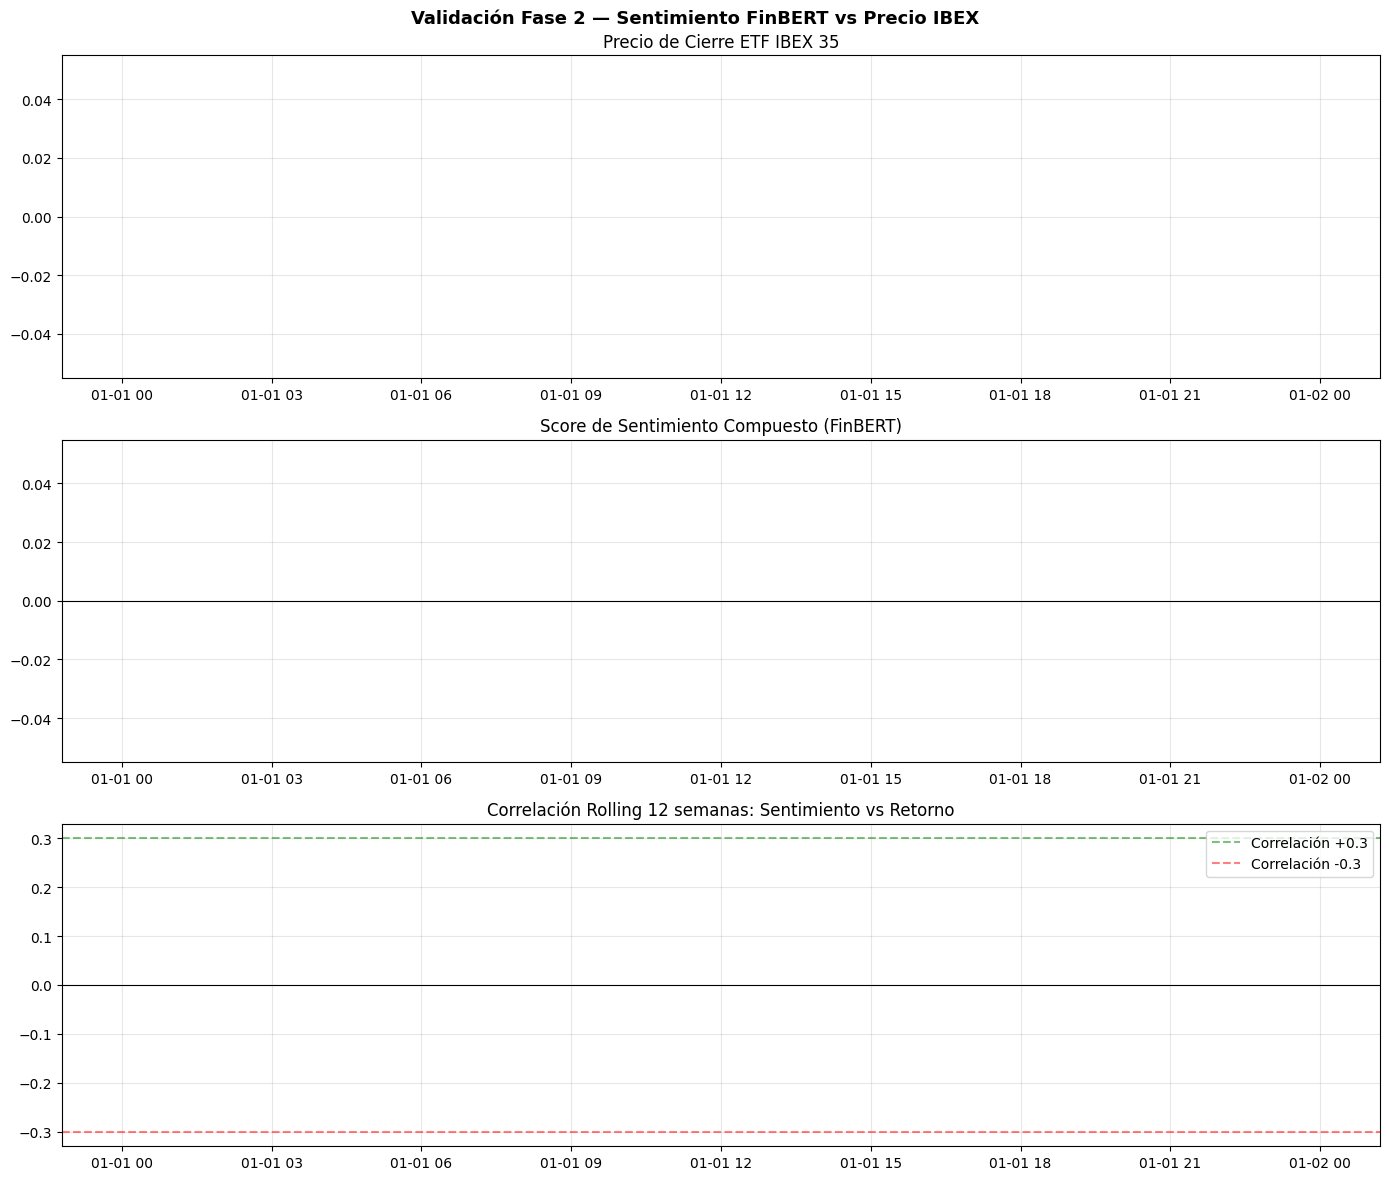


📊 Correlación global sentimiento → retorno: nan
   (Un valor de 0.1–0.4 es normal y útil para el modelo)


In [10]:
# Celda 8 — Validación: correlación sentimiento vs precio

import matplotlib.pyplot as plt

df_price = pd.read_csv(CONFIG["RAW_FILE"], index_col="date", parse_dates=True)
df_sent  = pd.read_csv(CONFIG["SENTIMENT_FILE"], index_col="date", parse_dates=True)

# Alinear índices
df_merged_val = df_price[["close", "return_1w"]].join(df_sent[["sentiment_compound_mean", "sentiment_bull_ratio"]], how="inner")

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Validación Fase 2 — Sentimiento FinBERT vs Precio IBEX", fontsize=13, fontweight="bold")

# 1. Precio
ax1 = axes[0]
ax1.plot(df_merged_val.index, df_merged_val["close"], color="#2196F3", linewidth=1.5)
ax1.set_title("Precio de Cierre ETF IBEX 35")
ax1.grid(True, alpha=0.3)

# 2. Sentimiento compuesto
ax2 = axes[1]
colors = ["#4CAF50" if x > 0 else "#F44336" for x in df_merged_val["sentiment_compound_mean"]]
ax2.bar(df_merged_val.index, df_merged_val["sentiment_compound_mean"], color=colors, alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Score de Sentimiento Compuesto (FinBERT)")
ax2.grid(True, alpha=0.3)

# 3. Correlación rolling
ax3 = axes[2]
rolling_corr = df_merged_val["sentiment_compound_mean"].rolling(12).corr(df_merged_val["return_1w"])
ax3.plot(df_merged_val.index, rolling_corr, color="#9C27B0", linewidth=1.5)
ax3.axhline(0, color="black", linewidth=0.8)
ax3.axhline(0.3, color="green", linestyle="--", alpha=0.5, label="Correlación +0.3")
ax3.axhline(-0.3, color="red", linestyle="--", alpha=0.5, label="Correlación -0.3")
ax3.set_title("Correlación Rolling 12 semanas: Sentimiento vs Retorno")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['DATA_DIR']}/sentiment_validation.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlación global
corr = df_merged_val["sentiment_compound_mean"].corr(df_merged_val["return_1w"])
print(f"\n📊 Correlación global sentimiento → retorno: {corr:.4f}")
print("   (Un valor de 0.1–0.4 es normal y útil para el modelo)")